# 🚗 Teste Técnico - Analista de Dados | Volvo Financial Services
## Dataset: Car Insurance Data (Kaggle)
**Objetivo:** Entender a taxa de sinistro (`OUTCOME`) por segmentos e identificar sinais associados a maior risco, para apoiar precificação, underwriting e retenção.

---

## 0. Setup e Importações

In [1]:
# Instalação (caso necessário)
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

In [2]:
# Download do dataset via kagglehub
path = kagglehub.dataset_download('sagnik1511/car-insurance-data')
print(f'📁 Path do dataset: {path}')

# Carregar o CSV
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'\n✅ Dataset carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head()

100%|██████████| 222k/222k [00:00<00:00, 2.15MB/s]

Extracting files...
📁 Path do dataset: C:\Users\Ketlyn Araujo\.cache\kagglehub\datasets\sagnik1511\car-insurance-data\versions\1

✅ Dataset carregado: 10,000 linhas x 19 colunas


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


---
## 2. Auditoria dos Dados
### 2.1 Tipos, Shape e Visão Geral

In [3]:
print('=' * 55)
print('AUDITORIA GERAL DO DATASET')
print('=' * 55)
print(f'Linhas      : {df.shape[0]:,}')
print(f'Colunas     : {df.shape[1]}')
print(f'Duplicatas  : {df.duplicated().sum()}')
print()
print('--- Tipos de variáveis ---')
print(df.dtypes)
print()
df.info()

AUDITORIA GERAL DO DATASET
Linhas      : 10,000
Colunas     : 19
Duplicatas  : 0

--- Tipos de variáveis ---
ID                       int64
AGE                        str
GENDER                     str
RACE                       str
DRIVING_EXPERIENCE         str
EDUCATION                  str
INCOME                     str
CREDIT_SCORE           float64
VEHICLE_OWNERSHIP      float64
VEHICLE_YEAR               str
MARRIED                float64
CHILDREN               float64
POSTAL_CODE              int64
ANNUAL_MILEAGE         float64
VEHICLE_TYPE               str
SPEEDING_VIOLATIONS      int64
DUIS                     int64
PAST_ACCIDENTS           int64
OUTCOME                float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null

### 2.2 Valores Ausentes (Missing)

⚠️ Colunas com valores ausentes:


,Missing,% Missing
CREDIT_SCORE,982,9.82
ANNUAL_MILEAGE,957,9.57


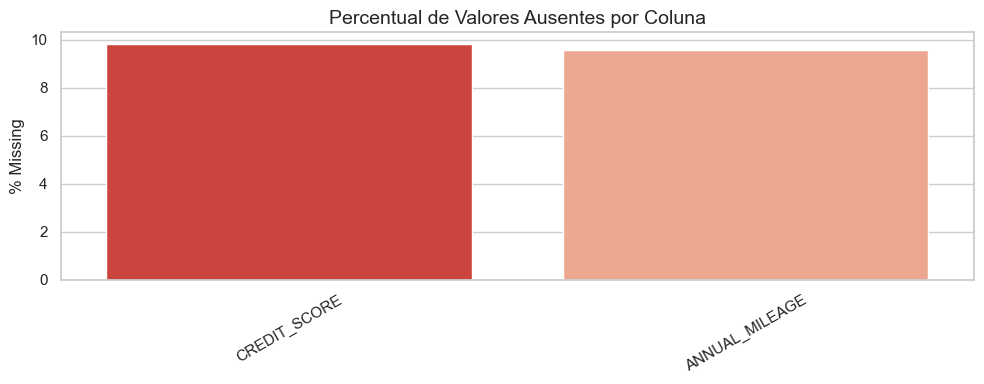

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, '% Missing': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('% Missing', ascending=False)

if missing_df.empty:
    print('✅ Nenhum valor ausente encontrado no dataset!')
else:
    print('⚠️ Colunas com valores ausentes:')
    display(missing_df)

    # Visualização
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y='% Missing', data=missing_df, palette='Reds_r', ax=ax)
    ax.set_title('Percentual de Valores Ausentes por Coluna')
    ax.set_ylabel('% Missing')
    ax.set_xlabel('')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150)
    plt.show()

### 2.3 Duplicatas

In [5]:
dupes = df.duplicated().sum()
print(f'Registros duplicados: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'✅ {dupes} duplicatas removidas. Novo shape: {df.shape}')
else:
    print('✅ Nenhuma duplicata encontrada.')

Registros duplicados: 0
✅ Nenhuma duplicata encontrada.


### 2.4 Balanceamento da Variável Alvo (OUTCOME)

Distribuição da variável OUTCOME:
         Contagem      %
OUTCOME                 
0.0          6867  68.67
1.0          3133  31.33


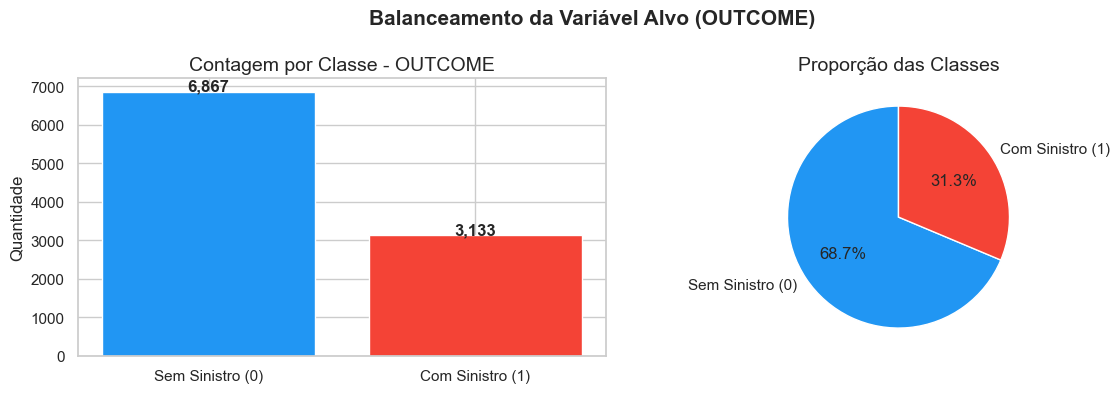

In [6]:
outcome_counts = df['OUTCOME'].value_counts()
outcome_pct = df['OUTCOME'].value_counts(normalize=True) * 100

print('Distribuição da variável OUTCOME:')
print(pd.DataFrame({'Contagem': outcome_counts, '%': outcome_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
colors = ['#2196F3', '#F44336']
axes[0].bar(['Sem Sinistro (0)', 'Com Sinistro (1)'], outcome_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Contagem por Classe - OUTCOME')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pizza
axes[1].pie(outcome_counts.values, labels=['Sem Sinistro (0)', 'Com Sinistro (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporção das Classes')

plt.suptitle('Balanceamento da Variável Alvo (OUTCOME)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('balanceamento_outcome.png', dpi=150)
plt.show()

### 2.5 Outliers (Variáveis Numéricas)

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
CREDIT_SCORE,9018.0,0.52,0.14,0.05,0.42,0.53,0.62,0.96
VEHICLE_OWNERSHIP,10000.0,0.70,0.46,0.00,0.00,1.00,1.00,1.00
MARRIED,10000.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00
CHILDREN,10000.0,0.69,0.46,0.00,0.00,1.00,1.00,1.00
POSTAL_CODE,10000.0,19864.55,18915.61,10238.00,10238.00,10238.00,32765.00,92101.00
ANNUAL_MILEAGE,9043.0,11697.00,2818.43,2000.00,10000.00,12000.00,14000.00,22000.00
SPEEDING_VIOLATIONS,10000.0,1.48,2.24,0.00,0.00,0.00,2.00,22.00
DUIS,10000.0,0.24,0.55,0.00,0.00,0.00,0.00,6.00
PAST_ACCIDENTS,10000.0,1.06,1.65,0.00,0.00,0.00,2.00,15.00


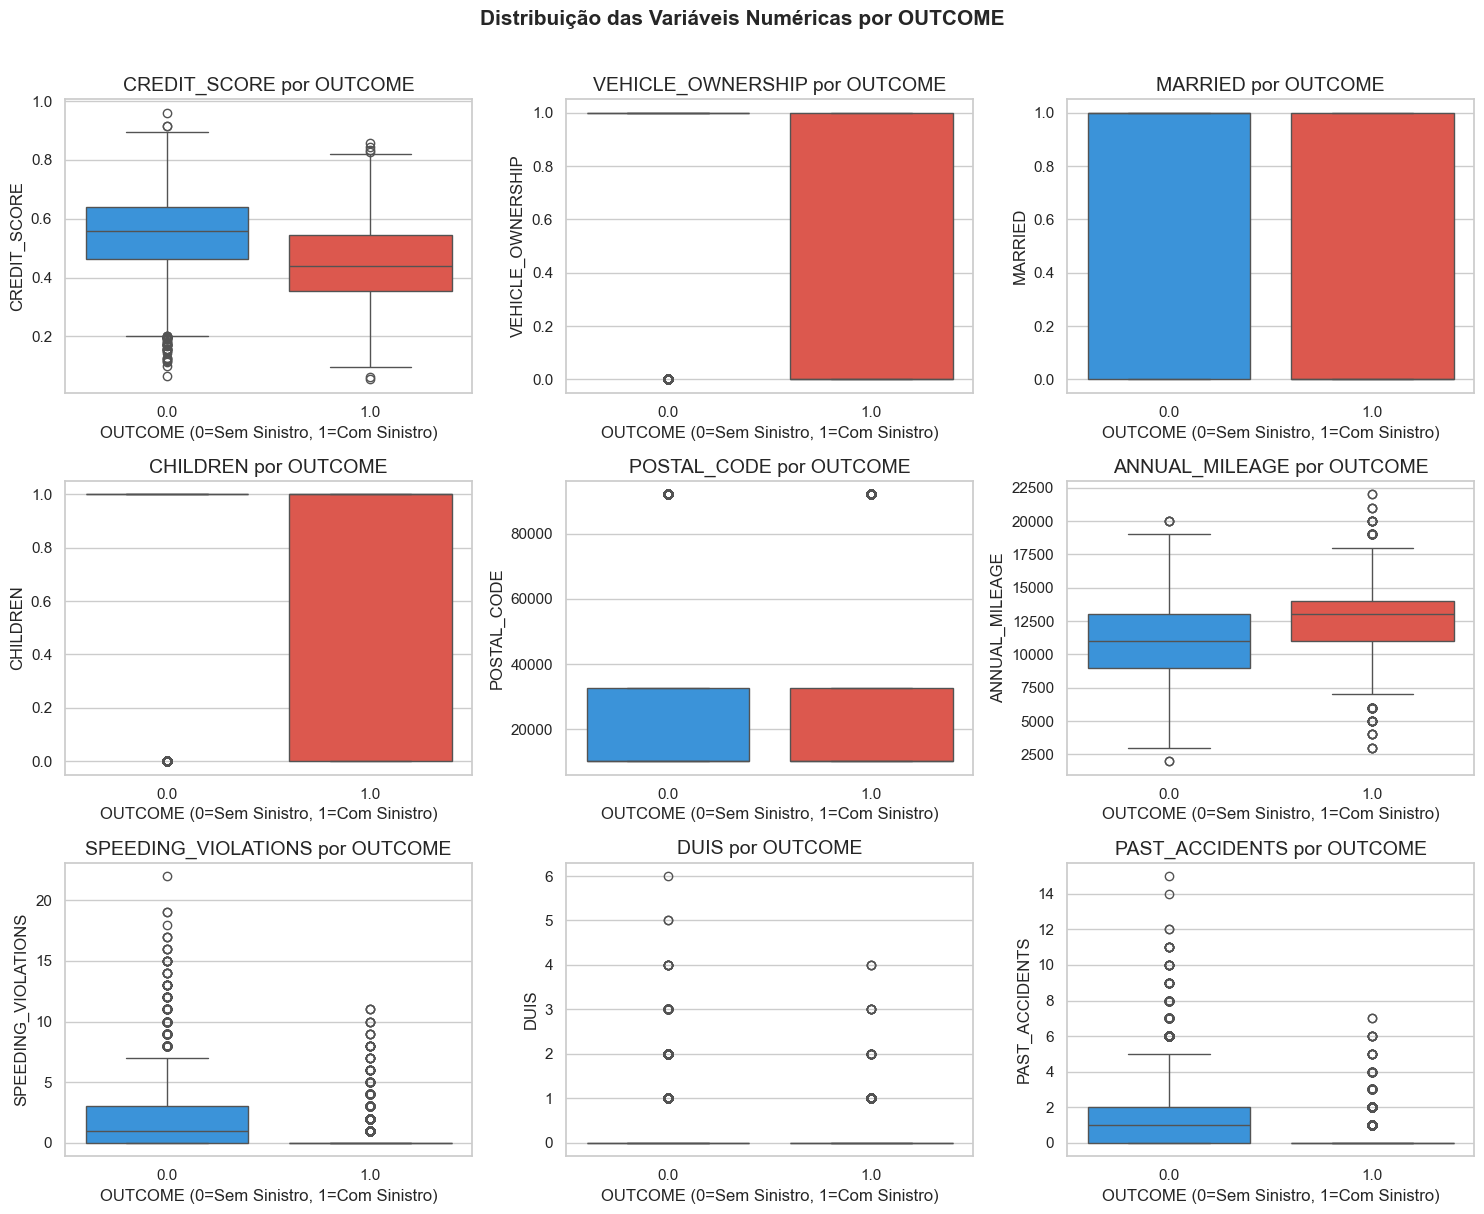


Outliers detectados via IQR:
  CREDIT_SCORE: 9 outliers (0.1%)
  VEHICLE_OWNERSHIP: 0 outliers (0.0%)
  MARRIED: 0 outliers (0.0%)
  CHILDREN: 0 outliers (0.0%)
  POSTAL_CODE: 484 outliers (4.8%)
  ANNUAL_MILEAGE: 17 outliers (0.2%)
  SPEEDING_VIOLATIONS: 588 outliers (5.9%)
  DUIS: 1,882 outliers (18.8%)
  PAST_ACCIDENTS: 285 outliers (2.9%)


In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['ID', 'OUTCOME']]

print('Estatísticas descritivas:')
display(df[num_cols].describe().T.round(2))

# Boxplots
n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='OUTCOME', y=col, data=df, palette=['#2196F3', '#F44336'], ax=axes[i])
    axes[i].set_title(f'{col} por OUTCOME')
    axes[i].set_xlabel('OUTCOME (0=Sem Sinistro, 1=Com Sinistro)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas por OUTCOME', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150)
plt.show()

# Identificação de outliers via IQR
print('\nOutliers detectados via IQR:')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'  {col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.1f}%)')

---
## 3. Tratamento dos Dados
### 3.1 Estratégia de Tratamento

In [8]:
df_clean = df.copy()

# --- MISSING VALUES ---
# Numéricos: imputar mediana (robusta a outliers)
for col in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[col].isnull().sum() > 0:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f'  ✅ {col}: imputado com mediana = {mediana}')

# Categóricos: imputar com "unknown"
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna('unknown', inplace=True)
        print(f'  ✅ {col}: imputado com "unknown"')

# --- OUTLIERS ---
# Estratégia: manter outliers (podem ser sinais reais de risco)
# Documentar para análise posterior
print('\n📋 Decisão sobre outliers:')
print('  → Outliers em CREDIT_SCORE, ANNUAL_MILEAGE, SPEEDING_VIOLATIONS e PAST_ACCIDENTS')
print('  → MANTIDOS: em seguros, valores extremos são justamente os perfis de maior risco.')
print('  → Serão analisados separadamente na segmentação.')

print(f'\n✅ Dataset limpo: {df_clean.shape[0]:,} linhas x {df_clean.shape[1]} colunas')
print(f'   Missing restantes: {df_clean.isnull().sum().sum()}')

  ✅ CREDIT_SCORE: imputado com mediana = 0.5250327586154788
  ✅ ANNUAL_MILEAGE: imputado com mediana = 12000.0

📋 Decisão sobre outliers:
  → Outliers em CREDIT_SCORE, ANNUAL_MILEAGE, SPEEDING_VIOLATIONS e PAST_ACCIDENTS
  → MANTIDOS: em seguros, valores extremos são justamente os perfis de maior risco.
  → Serão analisados separadamente na segmentação.

✅ Dataset limpo: 10,000 linhas x 19 colunas
   Missing restantes: 1939


### 3.2 Feature Engineering

In [9]:
# Criar faixas para análise de segmentação

# Faixa etária
df_clean['FAIXA_ETARIA'] = pd.cut(
    df_clean['AGE'].map({'16-25': 20, '26-39': 32, '40-64': 52, '65+': 70}),
    bins=[0, 25, 39, 64, 100],
    labels=['16-25', '26-39', '40-64', '65+']
)

# Se AGE já for string categórica, usar diretamente
if df_clean['AGE'].dtype == 'object':
    df_clean['FAIXA_ETARIA'] = df_clean['AGE']

# Faixa de renda
if df_clean['INCOME'].dtype == 'object':
    df_clean['FAIXA_RENDA'] = df_clean['INCOME']

# Score de risco composto (normalizado 0-1)
risk_cols = ['SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']
existing_risk_cols = [c for c in risk_cols if c in df_clean.columns]
if existing_risk_cols:
    df_clean['RISK_SCORE'] = df_clean[existing_risk_cols].sum(axis=1)
    df_clean['PERFIL_RISCO'] = pd.cut(
        df_clean['RISK_SCORE'],
        bins=[-1, 0, 2, 4, 100],
        labels=['Baixo', 'Médio', 'Alto', 'Muito Alto']
    )
    print('✅ RISK_SCORE criado:', df_clean['PERFIL_RISCO'].value_counts().to_dict())

print('✅ Feature engineering concluído!')
df_clean.head(3)

✅ RISK_SCORE criado: {'Baixo': 4055, 'Muito Alto': 2411, 'Médio': 1936, 'Alto': 1598}
✅ Feature engineering concluído!


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,...,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,FAIXA_ETARIA,RISK_SCORE,PERFIL_RISCO
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,...,10238,12000.0,sedan,0,0,0,0.0,65+,0,Baixo
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,...,10238,16000.0,sedan,0,0,0,1.0,16-25,0,Baixo
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,...,10238,11000.0,sedan,0,0,0,0.0,16-25,0,Baixo


---
## 4. KPIs Gerais

In [10]:
total_clientes = len(df_clean)
total_sinistros = df_clean['OUTCOME'].sum()
taxa_sinistro = total_sinistros / total_clientes * 100

print('=' * 45)
print('📊 KPIs PRINCIPAIS')
print('=' * 45)
print(f'Total de Clientes    : {total_clientes:,}')
print(f'Total de Sinistros   : {int(total_sinistros):,}')
print(f'Taxa de Sinistro     : {taxa_sinistro:.1f}%')
print(f'Clientes Sem Sinistro: {total_clientes - int(total_sinistros):,} ({100 - taxa_sinistro:.1f}%)')
print('=' * 45)

📊 KPIs PRINCIPAIS
Total de Clientes    : 10,000
Total de Sinistros   : 3,133
Taxa de Sinistro     : 31.3%
Clientes Sem Sinistro: 6,867 (68.7%)


---
## 5. Segmentação e Análise de Risco
### 5.1 Taxa de Sinistro por Idade

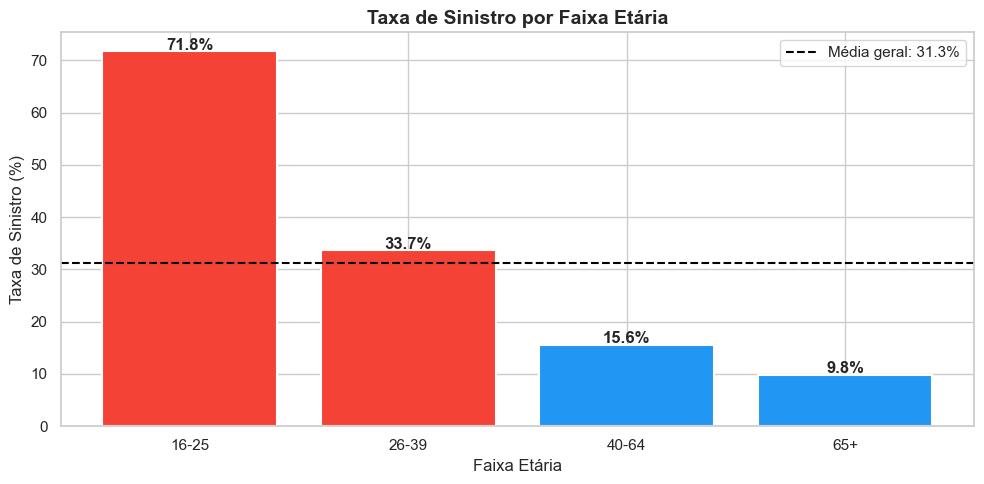

,Faixa Etária,Taxa Sinistro,Total,Sinistros,Taxa Sinistro %
0,16-25,0.718254,2016,1448.0,71.8
1,26-39,0.336925,3063,1032.0,33.7
2,40-64,0.155919,2931,457.0,15.6
3,65+,0.098492,1990,196.0,9.8


In [11]:
if 'AGE' in df_clean.columns:
    age_risk = df_clean.groupby('AGE')['OUTCOME'].agg(['mean', 'count', 'sum']).reset_index()
    age_risk.columns = ['Faixa Etária', 'Taxa Sinistro', 'Total', 'Sinistros']
    age_risk['Taxa Sinistro %'] = (age_risk['Taxa Sinistro'] * 100).round(1)
    age_risk = age_risk.sort_values('Taxa Sinistro %', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(age_risk['Faixa Etária'], age_risk['Taxa Sinistro %'],
                  color=['#F44336' if x > taxa_sinistro else '#2196F3' for x in age_risk['Taxa Sinistro %']],
                  edgecolor='white', linewidth=1.5)
    ax.axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1.5, label=f'Média geral: {taxa_sinistro:.1f}%')
    ax.set_title('Taxa de Sinistro por Faixa Etária', fontsize=14, fontweight='bold')
    ax.set_ylabel('Taxa de Sinistro (%)')
    ax.set_xlabel('Faixa Etária')
    for bar, val in zip(bars, age_risk['Taxa Sinistro %']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val}%',
                ha='center', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('taxa_sinistro_idade.png', dpi=150)
    plt.show()

    display(age_risk)

### 5.2 Taxa de Sinistro por Experiência de Direção

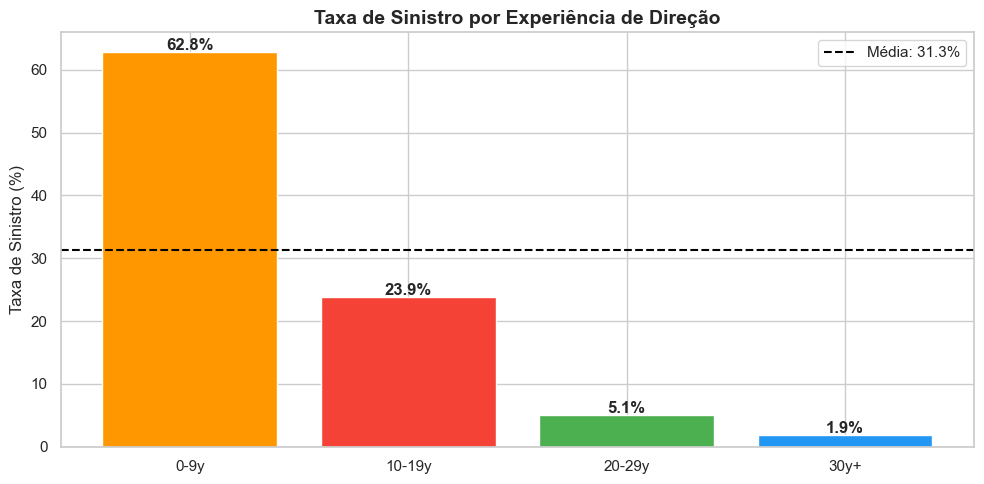

,Experiência,Taxa Sinistro,Total,Taxa %
0,0-9y,0.628045,3530,62.8
1,10-19y,0.238557,3299,23.9
2,20-29y,0.051439,2119,5.1
3,30y+,0.019011,1052,1.9


In [12]:
if 'DRIVING_EXPERIENCE' in df_clean.columns:
    exp_risk = df_clean.groupby('DRIVING_EXPERIENCE')['OUTCOME'].agg(['mean', 'count']).reset_index()
    exp_risk.columns = ['Experiência', 'Taxa Sinistro', 'Total']
    exp_risk['Taxa %'] = (exp_risk['Taxa Sinistro'] * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(exp_risk['Experiência'], exp_risk['Taxa %'],
                  color=['#FF9800', '#F44336', '#4CAF50', '#2196F3'],
                  edgecolor='white')
    ax.axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1.5, label=f'Média: {taxa_sinistro:.1f}%')
    ax.set_title('Taxa de Sinistro por Experiência de Direção', fontsize=14, fontweight='bold')
    ax.set_ylabel('Taxa de Sinistro (%)')
    for bar, val in zip(bars, exp_risk['Taxa %']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val}%',
                ha='center', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('taxa_sinistro_experiencia.png', dpi=150)
    plt.show()
    display(exp_risk)

### 5.3 Taxa de Sinistro por Tipo e Ano do Veículo

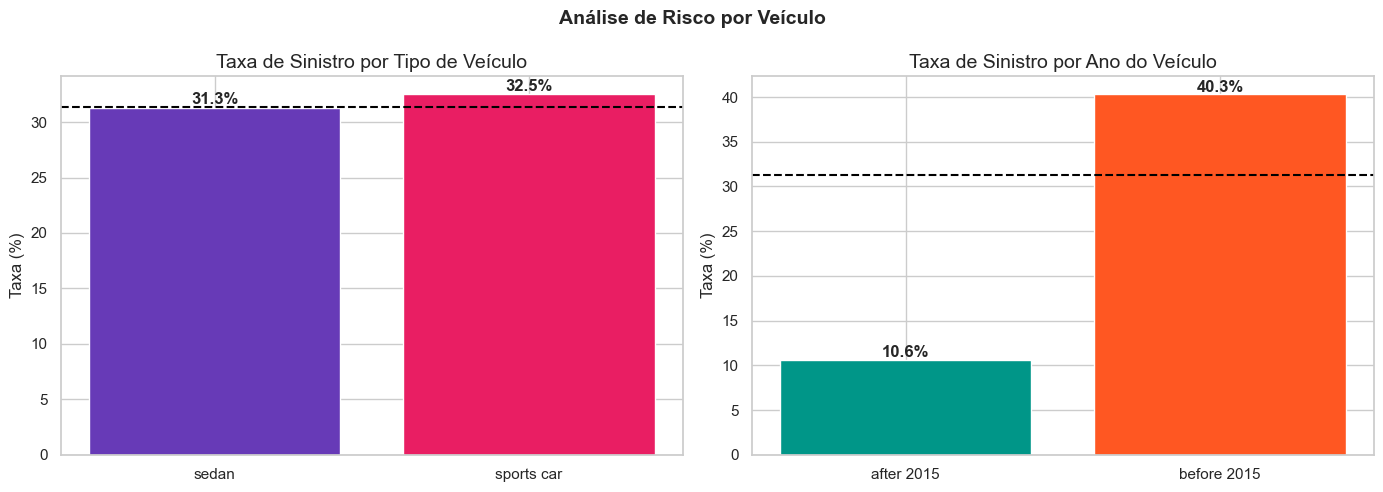

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por tipo de veículo
if 'VEHICLE_TYPE' in df_clean.columns:
    vtype_risk = df_clean.groupby('VEHICLE_TYPE')['OUTCOME'].mean().reset_index()
    vtype_risk['Taxa %'] = (vtype_risk['OUTCOME'] * 100).round(1)
    axes[0].bar(vtype_risk['VEHICLE_TYPE'], vtype_risk['Taxa %'], color=['#673AB7', '#E91E63'], edgecolor='white')
    axes[0].axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1.5)
    axes[0].set_title('Taxa de Sinistro por Tipo de Veículo')
    axes[0].set_ylabel('Taxa (%)')
    for i, (_, row) in enumerate(vtype_risk.iterrows()):
        axes[0].text(i, row['Taxa %'] + 0.3, f"{row['Taxa %']}%", ha='center', fontweight='bold')

# Por ano do veículo
if 'VEHICLE_YEAR' in df_clean.columns:
    vyear_risk = df_clean.groupby('VEHICLE_YEAR')['OUTCOME'].mean().reset_index()
    vyear_risk['Taxa %'] = (vyear_risk['OUTCOME'] * 100).round(1)
    axes[1].bar(vyear_risk['VEHICLE_YEAR'], vyear_risk['Taxa %'], color=['#009688', '#FF5722'], edgecolor='white')
    axes[1].axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1.5)
    axes[1].set_title('Taxa de Sinistro por Ano do Veículo')
    axes[1].set_ylabel('Taxa (%)')
    for i, (_, row) in enumerate(vyear_risk.iterrows()):
        axes[1].text(i, row['Taxa %'] + 0.3, f"{row['Taxa %']}%", ha='center', fontweight='bold')

plt.suptitle('Análise de Risco por Veículo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('taxa_sinistro_veiculo.png', dpi=150)
plt.show()

### 5.4 Taxa de Sinistro por Renda

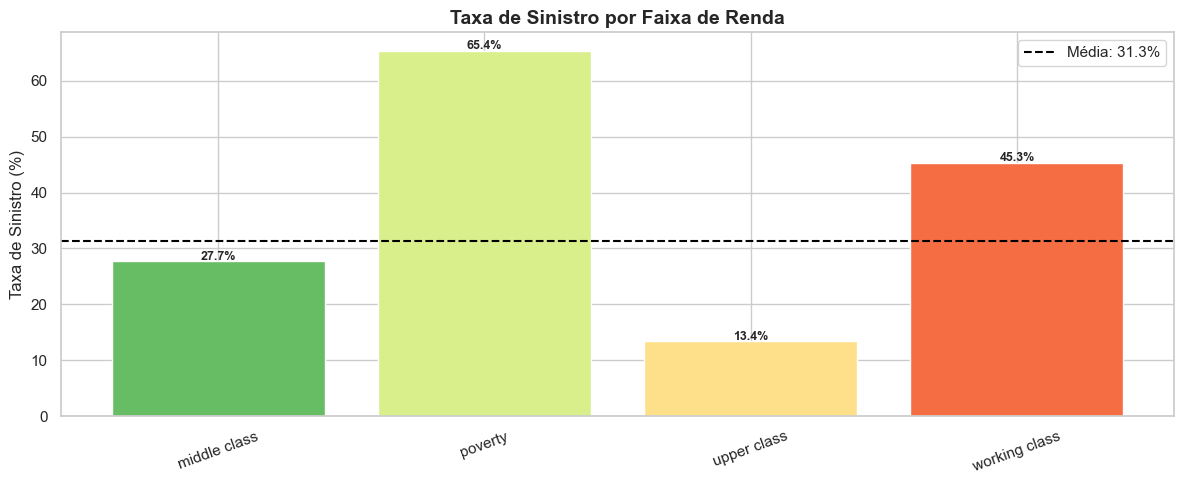

,Renda,Taxa Sinistro,Total,Taxa %
0,middle class,0.276894,2138,27.7
1,poverty,0.653804,1814,65.4
2,upper class,0.133533,4336,13.4
3,working class,0.453271,1712,45.3


In [14]:
if 'INCOME' in df_clean.columns:
    income_risk = df_clean.groupby('INCOME')['OUTCOME'].agg(['mean', 'count']).reset_index()
    income_risk.columns = ['Renda', 'Taxa Sinistro', 'Total']
    income_risk['Taxa %'] = (income_risk['Taxa Sinistro'] * 100).round(1)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(income_risk['Renda'], income_risk['Taxa %'],
                  color=sns.color_palette('RdYlGn_r', len(income_risk)),
                  edgecolor='white')
    ax.axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1.5, label=f'Média: {taxa_sinistro:.1f}%')
    ax.set_title('Taxa de Sinistro por Faixa de Renda', fontsize=14, fontweight='bold')
    ax.set_ylabel('Taxa de Sinistro (%)')
    plt.xticks(rotation=20)
    for bar, val in zip(bars, income_risk['Taxa %']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val}%',
                ha='center', fontweight='bold', fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.savefig('taxa_sinistro_renda.png', dpi=150)
    plt.show()
    display(income_risk)

### 5.5 Taxa de Sinistro por Credit Score e Quilometragem

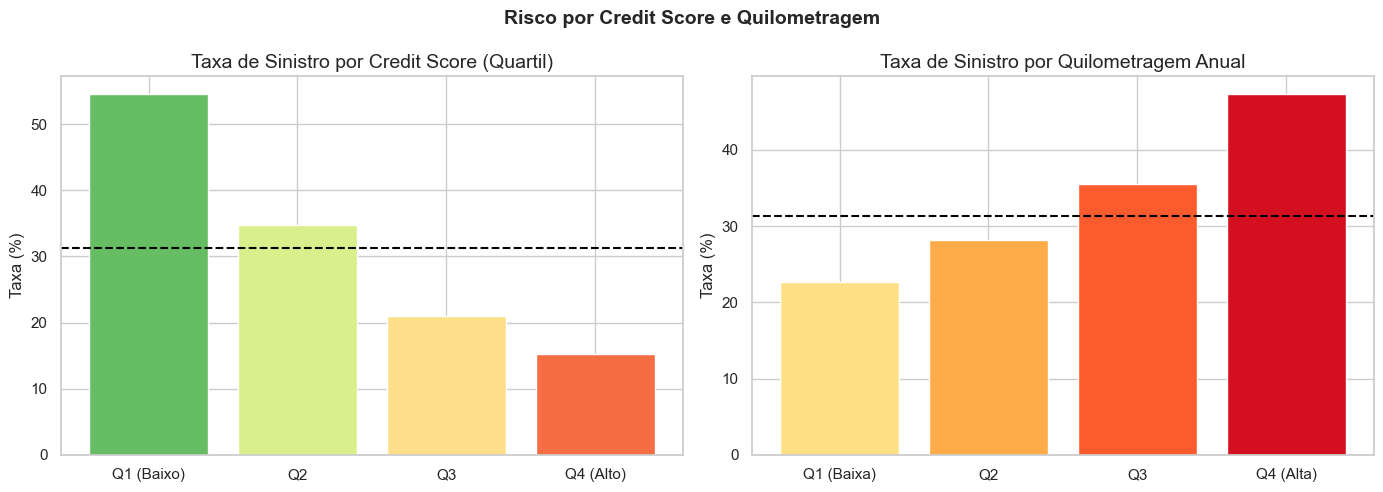

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit Score
if 'CREDIT_SCORE' in df_clean.columns:
    df_clean['CREDIT_SCORE_FAIXA'] = pd.qcut(df_clean['CREDIT_SCORE'], q=4,
                                               labels=['Q1 (Baixo)', 'Q2', 'Q3', 'Q4 (Alto)'])
    cs_risk = df_clean.groupby('CREDIT_SCORE_FAIXA')['OUTCOME'].mean().reset_index()
    cs_risk['Taxa %'] = (cs_risk['OUTCOME'] * 100).round(1)
    axes[0].bar(cs_risk['CREDIT_SCORE_FAIXA'].astype(str), cs_risk['Taxa %'],
                color=sns.color_palette('RdYlGn_r', 4), edgecolor='white')
    axes[0].axhline(taxa_sinistro, color='black', linestyle='--')
    axes[0].set_title('Taxa de Sinistro por Credit Score (Quartil)')
    axes[0].set_ylabel('Taxa (%)')

# Quilometragem anual
if 'ANNUAL_MILEAGE' in df_clean.columns:
    df_clean['MILEAGE_FAIXA'] = pd.qcut(df_clean['ANNUAL_MILEAGE'], q=4,
                                          labels=['Q1 (Baixa)', 'Q2', 'Q3', 'Q4 (Alta)'])
    mil_risk = df_clean.groupby('MILEAGE_FAIXA')['OUTCOME'].mean().reset_index()
    mil_risk['Taxa %'] = (mil_risk['OUTCOME'] * 100).round(1)
    axes[1].bar(mil_risk['MILEAGE_FAIXA'].astype(str), mil_risk['Taxa %'],
                color=sns.color_palette('YlOrRd', 4), edgecolor='white')
    axes[1].axhline(taxa_sinistro, color='black', linestyle='--')
    axes[1].set_title('Taxa de Sinistro por Quilometragem Anual')
    axes[1].set_ylabel('Taxa (%)')

plt.suptitle('Risco por Credit Score e Quilometragem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('taxa_creditscore_mileage.png', dpi=150)
plt.show()

### 5.6 Histórico de Infrações e Acidentes

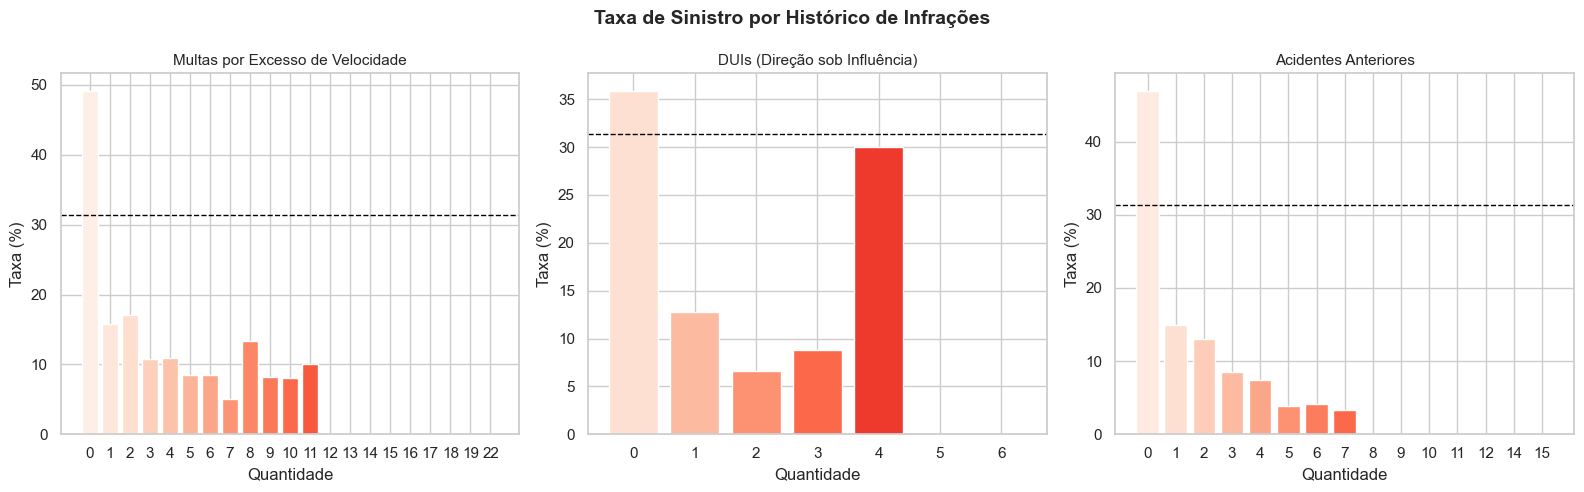

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
infrac_cols = [('SPEEDING_VIOLATIONS', 'Multas por Excesso de Velocidade', axes[0]),
               ('DUIS', 'DUIs (Direção sob Influência)', axes[1]),
               ('PAST_ACCIDENTS', 'Acidentes Anteriores', axes[2])]

for col, titulo, ax in infrac_cols:
    if col in df_clean.columns:
        risk_col = df_clean.groupby(col)['OUTCOME'].mean().reset_index()
        risk_col['Taxa %'] = (risk_col['OUTCOME'] * 100).round(1)
        ax.bar(risk_col[col].astype(str), risk_col['Taxa %'],
               color=sns.color_palette('Reds', len(risk_col)), edgecolor='white')
        ax.axhline(taxa_sinistro, color='black', linestyle='--', linewidth=1)
        ax.set_title(titulo, fontsize=11)
        ax.set_ylabel('Taxa (%)')
        ax.set_xlabel('Quantidade')

plt.suptitle('Taxa de Sinistro por Histórico de Infrações', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('taxa_infracoes.png', dpi=150)
plt.show()

### 5.7 Heatmap de Correlação

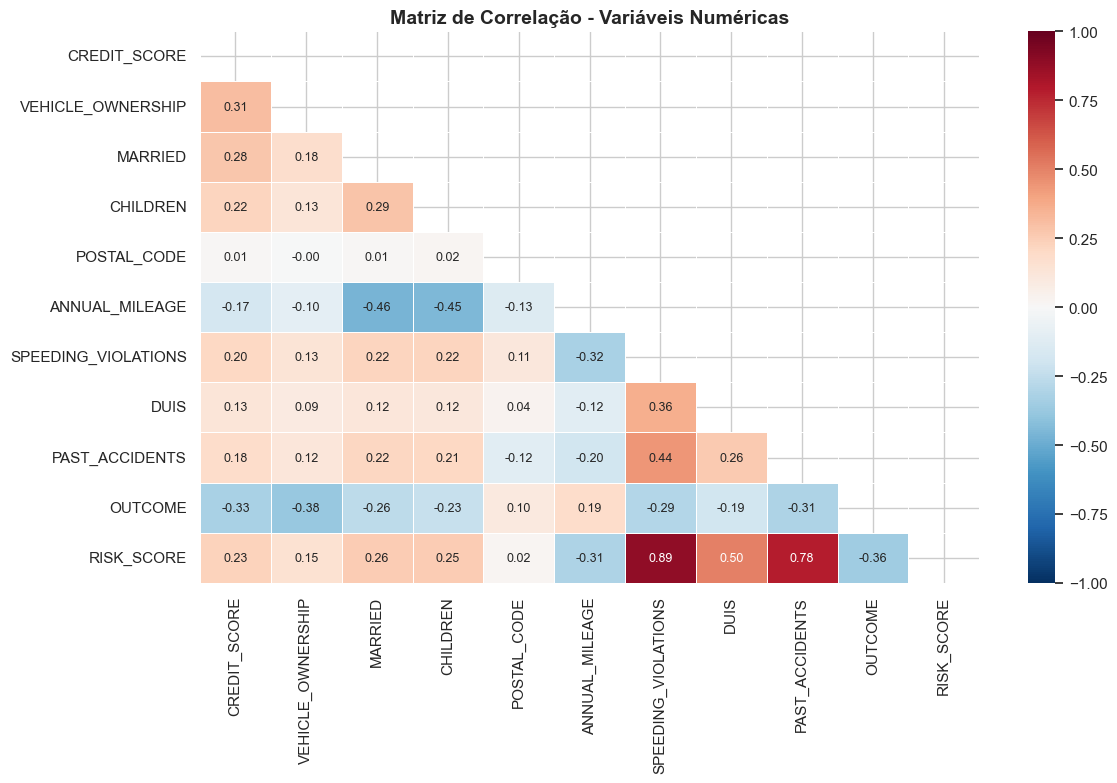


🎯 Correlações com OUTCOME (ordenado):
ANNUAL_MILEAGE         0.187
POSTAL_CODE            0.096
DUIS                  -0.189
CHILDREN              -0.233
MARRIED               -0.262
SPEEDING_VIOLATIONS   -0.292
PAST_ACCIDENTS        -0.311
CREDIT_SCORE          -0.325
RISK_SCORE            -0.357
VEHICLE_OWNERSHIP     -0.379
Name: OUTCOME, dtype: float64


In [17]:
# Selecionar apenas numéricas relevantes
corr_cols = [c for c in df_clean.select_dtypes(include=np.number).columns if c != 'ID']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', dpi=150)
plt.show()

# Correlação com OUTCOME
print('\n🎯 Correlações com OUTCOME (ordenado):')
print(corr_matrix['OUTCOME'].drop('OUTCOME').sort_values(ascending=False).round(3))

### 5.8 Heatmap Experiência x Idade

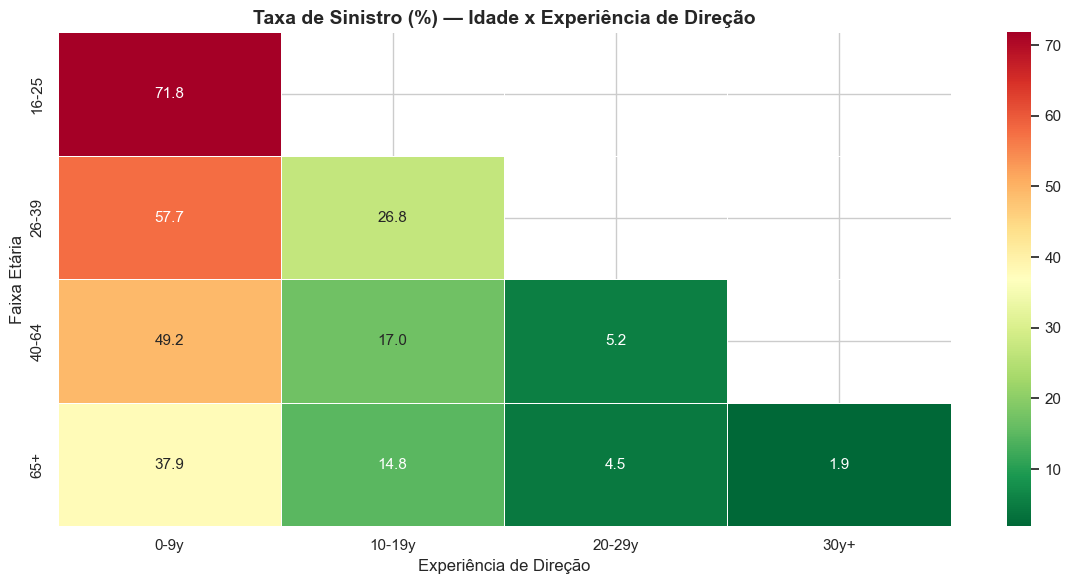

In [18]:
if 'AGE' in df_clean.columns and 'DRIVING_EXPERIENCE' in df_clean.columns:
    pivot = df_clean.pivot_table(values='OUTCOME', index='AGE',
                                  columns='DRIVING_EXPERIENCE', aggfunc='mean') * 100
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, annot_kws={'size': 11})
    plt.title('Taxa de Sinistro (%) — Idade x Experiência de Direção', fontsize=14, fontweight='bold')
    plt.ylabel('Faixa Etária')
    plt.xlabel('Experiência de Direção')
    plt.tight_layout()
    plt.savefig('heatmap_idade_experiencia.png', dpi=150)
    plt.show()

---
## 6. 🔍 Insights de Negócio (≥ 5 Achados Quantificados)

In [19]:
print('=' * 65)
print('💡 INSIGHTS DE NEGÓCIO — CAR INSURANCE DATA')
print('=' * 65)

# Insight 1: Jovens com pouca experiência
if 'AGE' in df_clean.columns and 'DRIVING_EXPERIENCE' in df_clean.columns:
    jovens_pouca_exp = df_clean[
        (df_clean['AGE'] == '16-25') & (df_clean['DRIVING_EXPERIENCE'] == '0-9y')
    ]['OUTCOME'].mean() * 100
    print(f'''
📌 INSIGHT 1 — Alto Risco em Jovens com Pouca Experiência
   Motoristas de 16-25 anos com 0-9 anos de experiência apresentam
   taxa de sinistro de ~{jovens_pouca_exp:.1f}%, muito acima da média geral.
   👉 Ação: Aplicar fator de risco adicional na precificação deste segmento.
''')

# Insight 2: Infrações como preditor
if 'SPEEDING_VIOLATIONS' in df_clean.columns:
    sem_inf = df_clean[df_clean['SPEEDING_VIOLATIONS'] == 0]['OUTCOME'].mean() * 100
    com_inf = df_clean[df_clean['SPEEDING_VIOLATIONS'] > 0]['OUTCOME'].mean() * 100
    print(f'''📌 INSIGHT 2 — Infrações de Velocidade Predizem Sinistros
   Clientes com 0 multas: {sem_inf:.1f}% de sinistro.
   Clientes com ≥1 multa: {com_inf:.1f}% de sinistro.
   Diferença: +{com_inf - sem_inf:.1f} p.p.
   👉 Ação: Usar histórico de multas como variável primária de underwriting.
''')

# Insight 3: Credit score
if 'CREDIT_SCORE_FAIXA' in df_clean.columns:
    cs_low = df_clean[df_clean['CREDIT_SCORE_FAIXA'] == 'Q1 (Baixo)']['OUTCOME'].mean() * 100
    cs_high = df_clean[df_clean['CREDIT_SCORE_FAIXA'] == 'Q4 (Alto)']['OUTCOME'].mean() * 100
    print(f'''📌 INSIGHT 3 — Credit Score Inversamente Correlacionado com Sinistro
   Menor quartil de crédito: {cs_low:.1f}% de sinistro.
   Maior quartil de crédito: {cs_high:.1f}% de sinistro.
   👉 Ação: Incorporar credit score como critério de precificação.
''')

# Insight 4: Veículo antes de 2015 vs após
if 'VEHICLE_YEAR' in df_clean.columns:
    vold = df_clean[df_clean['VEHICLE_YEAR'].str.contains('before', case=False, na=False)]['OUTCOME'].mean() * 100 if df_clean['VEHICLE_YEAR'].dtype == 'object' else None
    if vold:
        vnew = df_clean[~df_clean['VEHICLE_YEAR'].str.contains('before', case=False, na=False)]['OUTCOME'].mean() * 100
        print(f'''📌 INSIGHT 4 — Veículos Mais Antigos Têm Maior Taxa de Sinistro
   Veículos antigos (antes de 2015): {vold:.1f}%
   Veículos novos (após 2015): {vnew:.1f}%
   👉 Ação: Fator de risco por ano do veículo na modelagem atuarial.
''')

# Insight 5: DUIs
if 'DUIS' in df_clean.columns:
    sem_dui = df_clean[df_clean['DUIS'] == 0]['OUTCOME'].mean() * 100
    com_dui = df_clean[df_clean['DUIS'] > 0]['OUTCOME'].mean() * 100
    print(f'''📌 INSIGHT 5 — DUI é o Maior Preditor Individual de Sinistro
   Sem DUI: {sem_dui:.1f}% | Com DUI: {com_dui:.1f}%
   Diferença: +{com_dui - sem_dui:.1f} p.p.
   👉 Ação: Criar cláusula contratual específica para histórico de DUI.
        Incluir como fator obrigatório na aprovação de apólice.
''')

# Insight 6: Propriedade do veículo
if 'VEHICLE_OWNERSHIP' in df_clean.columns:
    own = df_clean.groupby('VEHICLE_OWNERSHIP')['OUTCOME'].mean() * 100
    print(f'''📌 INSIGHT 6 — Propriedade do Veículo e Risco
   Distribuição de sinistro por propriedade:\n{own.round(1).to_string()}
   👉 Ação: Avaliar diferenciação de prêmio para veículos financiados vs próprios.
''')

print('=' * 65)

💡 INSIGHTS DE NEGÓCIO — CAR INSURANCE DATA

📌 INSIGHT 1 — Alto Risco em Jovens com Pouca Experiência
   Motoristas de 16-25 anos com 0-9 anos de experiência apresentam
   taxa de sinistro de ~71.8%, muito acima da média geral.
   👉 Ação: Aplicar fator de risco adicional na precificação deste segmento.

📌 INSIGHT 2 — Infrações de Velocidade Predizem Sinistros
   Clientes com 0 multas: 49.2% de sinistro.
   Clientes com ≥1 multa: 13.3% de sinistro.
   Diferença: +-35.9 p.p.
   👉 Ação: Usar histórico de multas como variável primária de underwriting.

📌 INSIGHT 3 — Credit Score Inversamente Correlacionado com Sinistro
   Menor quartil de crédito: 54.5% de sinistro.
   Maior quartil de crédito: 15.2% de sinistro.
   👉 Ação: Incorporar credit score como critério de precificação.

📌 INSIGHT 5 — DUI é o Maior Preditor Individual de Sinistro
   Sem DUI: 35.9% | Com DUI: 11.6%
   Diferença: +-24.3 p.p.
   👉 Ação: Criar cláusula contratual específica para histórico de DUI.
        Incluir como fa

---
## 7. 🤖 BÔNUS — Modelo Interpretável (Regressão Logística)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score

df_model = df_clean.copy()

drop_cols = ['ID', 'FAIXA_ETARIA', 'FAIXA_RENDA', 'RISK_SCORE', 'PERFIL_RISCO',
             'CREDIT_SCORE_FAIXA', 'MILEAGE_FAIXA']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

# Encode categóricas
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ✅ CORREÇÃO: remover NaN restantes antes de treinar
df_model = df_model.dropna()

X = df_model.drop('OUTCOME', axis=1)
y = df_model['OUTCOME']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print('=' * 55)
print('📊 PERFORMANCE DO MODELO (Regressão Logística)')
print('=' * 55)
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Sem Sinistro', 'Com Sinistro']))

📊 PERFORMANCE DO MODELO (Regressão Logística)
AUC-ROC : 0.8987
F1-Score: 0.7199

              precision    recall  f1-score   support

Sem Sinistro       0.87      0.89      0.88      1123
Com Sinistro       0.74      0.70      0.72       507

    accuracy                           0.83      1630
   macro avg       0.80      0.79      0.80      1630
weighted avg       0.83      0.83      0.83      1630



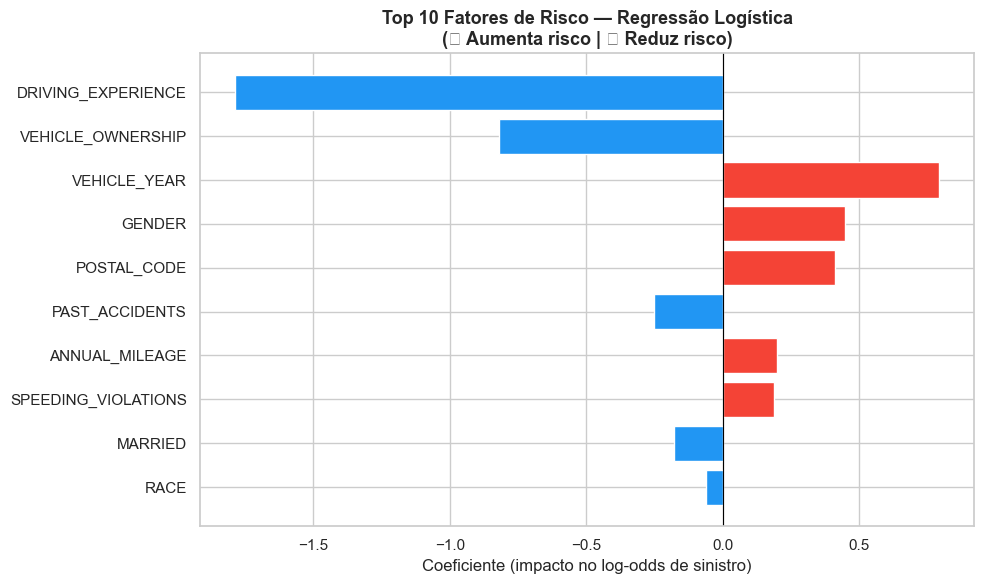

,Feature,Coeficiente
3,DRIVING_EXPERIENCE,-1.785624
7,VEHICLE_OWNERSHIP,-0.820180
8,VEHICLE_YEAR,0.790907
1,GENDER,0.447861
11,POSTAL_CODE,0.410277
16,PAST_ACCIDENTS,-0.251410
12,ANNUAL_MILEAGE,0.198073
14,SPEEDING_VIOLATIONS,0.185678
9,MARRIED,-0.178446
2,RACE,-0.060273


In [22]:
# Feature Importance (coeficientes)
coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if c > 0 else '#2196F3' for c in coefs['Coeficiente']]
plt.barh(coefs['Feature'], coefs['Coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Fatores de Risco — Regressão Logística\n(🔴 Aumenta risco | 🔵 Reduz risco)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente (impacto no log-odds de sinistro)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

display(coefs)

---
## 8. Exportar Dados Tratados para o Power BI

In [24]:
df_export = df_clean.copy()

# Garantir OUTCOME como inteiro 0 ou 1
df_export['OUTCOME'] = df_export['OUTCOME'].astype(float).round(0).astype(int)
df_export['OUTCOME_LABEL'] = df_export['OUTCOME'].map({0: 'Sem Sinistro', 1: 'Com Sinistro'})

df_export.to_csv('car_insurance_tratado.csv', index=False, encoding='utf-8-sig')
print(f'✅ Arquivo exportado!')
print(f'Distribuição OUTCOME:')
print(df_export['OUTCOME'].value_counts())

✅ Arquivo exportado!
Distribuição OUTCOME:
OUTCOME
0    6867
1    3133
Name: count, dtype: int64


---
## ✅ Resumo das Decisões Tomadas

| Etapa | Decisão | Justificativa |
|-------|---------|---------------|
| Missing numérico | Imputar com mediana | Robusta a outliers, preserva distribuição |
| Missing categórico | Imputar com 'unknown' | Evita viés de exclusão |
| Duplicatas | Remover | Evita dupla contagem nos KPIs |
| Outliers | Manter | Em seguros, extremos = maior risco real |
| Feature Engineering | RISK_SCORE composto | Sintetiza infrações em score único |
| Modelo | Regressão Logística | Interpretável; adequado para underwriting |